# EuRoC End-to-End Preprocessing and Split Pipeline

This notebook preprocesses raw EuRoC sequences from folders like `MH_01_easy/mav0`, creates per-sequence NumPy training windows, generates dataset splits, and saves reusable artifacts.

## 1. Install and Import Dependencies

In [1]:
# Uncomment and run if packages are missing.
# %pip install pandas numpy matplotlib seaborn scikit-learn

from pathlib import Path
import json
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib

sns.set_theme(style="whitegrid")

## 2. Configure Paths and Runtime Settings

In [2]:
# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Paths (Kaggle)
PROJECT_ROOT = Path("/kaggle/working")
RAW_DATA_ROOT = Path("/kaggle/input/datasets/bhavaniprasadm3/euroc-mav")

# Fallback for Kaggle mounted dataset folder name in the right pane
if not RAW_DATA_ROOT.exists():
    RAW_DATA_ROOT = Path("/kaggle/input/euroc_mav")

PROCESSED_ROOT = PROJECT_ROOT / "processed_data"
SEQUENCE_OUTPUT_DIR = PROCESSED_ROOT / "sequences"
SPLIT_DIR = PROCESSED_ROOT / "splits"
MODEL_DIR = PROCESSED_ROOT / "models"

for p in [PROCESSED_ROOT, SEQUENCE_OUTPUT_DIR, SPLIT_DIR, MODEL_DIR]:
    p.mkdir(parents=True, exist_ok=True)

# Window settings
WINDOW_SIZE = 200      # IMU samples
STRIDE = 20            # sliding step
HORIZON = 200          # prediction horizon in samples

# Display settings
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)

print("Project root:", PROJECT_ROOT)
print("Raw data root:", RAW_DATA_ROOT)
print("Raw data exists:", RAW_DATA_ROOT.exists())
print("Processed output:", PROCESSED_ROOT)

Project root: /kaggle/working
Raw data root: /kaggle/input/datasets/bhavaniprasadm3/euroc-mav
Raw data exists: True
Processed output: /kaggle/working/processed_data


## 3. Load Input Data

In [3]:
def discover_sequences(root: Path):
    seqs = []
    for p in root.iterdir():
        if p.is_dir() and (p / "mav0").exists():
            seqs.append(p)
    return sorted(seqs)


def load_imu_csv(mav0_dir: Path) -> pd.DataFrame:
    imu_path = mav0_dir / "imu0" / "data.csv"
    imu = pd.read_csv(
        imu_path,
        comment="#",
        header=None,
        names=["timestamp_ns", "gyro_x", "gyro_y", "gyro_z", "acc_x", "acc_y", "acc_z"],
    )
    return imu.sort_values("timestamp_ns").reset_index(drop=True)


def load_gt_csv(mav0_dir: Path) -> pd.DataFrame:
    gt_path = mav0_dir / "state_groundtruth_estimate0" / "data.csv"
    gt = pd.read_csv(
        gt_path,
        comment="#",
        header=None,
        names=[
            "timestamp_ns", "p_x", "p_y", "p_z", "q_w", "q_x", "q_y", "q_z",
            "v_x", "v_y", "v_z", "bw_x", "bw_y", "bw_z", "ba_x", "ba_y", "ba_z",
        ],
    )
    return gt.sort_values("timestamp_ns").reset_index(drop=True)


sequence_paths = discover_sequences(RAW_DATA_ROOT)
print(f"Discovered {len(sequence_paths)} sequence folder(s)")
print([p.name for p in sequence_paths][:10])

sample_seq = sequence_paths[0]
sample_mav0 = sample_seq / "mav0"
imu_df = load_imu_csv(sample_mav0)
gt_df = load_gt_csv(sample_mav0)

print("Sample sequence:", sample_seq.name)
print("IMU rows:", len(imu_df), "GT rows:", len(gt_df))
imu_df.head()

Discovered 9 sequence folder(s)
['MH_01_easy', 'MH_02_easy', 'MH_03_medium', 'MH_04_difficult', 'MH_05_difficult', 'V1_03_difficult', 'V2_01_easy', 'V2_02_medium', 'V2_03_difficult']
Sample sequence: MH_01_easy
IMU rows: 36820 GT rows: 36382


,timestamp_ns,gyro_x,gyro_y,gyro_z,acc_x,acc_y,acc_z
0,1403636579758555392,-0.099135,0.147306,0.027227,8.147692,-0.375922,-2.402629
1,1403636579763555584,-0.099135,0.140324,0.029322,8.033281,-0.408610,-2.402629
2,1403636579768555520,-0.098437,0.127758,0.037699,7.886181,-0.424955,-2.435318
3,1403636579773555456,-0.102625,0.115890,0.045379,7.828976,-0.375922,-2.468007
4,1403636579778555392,-0.105418,0.108210,0.051662,7.714565,-0.408610,-2.557901


## 4. Clean and Validate Data

In [4]:
def clean_and_validate(imu: pd.DataFrame, gt: pd.DataFrame):
    imu = imu.drop_duplicates(subset=["timestamp_ns"]).dropna().copy()
    gt = gt.drop_duplicates(subset=["timestamp_ns"]).dropna().copy()

    imu["timestamp_ns"] = imu["timestamp_ns"].astype(np.int64)
    gt["timestamp_ns"] = gt["timestamp_ns"].astype(np.int64)

    assert imu["timestamp_ns"].is_monotonic_increasing, "IMU timestamps must be sorted"
    assert gt["timestamp_ns"].is_monotonic_increasing, "GT timestamps must be sorted"

    return imu.reset_index(drop=True), gt.reset_index(drop=True)


def interpolate_gt_to_imu(imu: pd.DataFrame, gt: pd.DataFrame) -> pd.DataFrame:
    imu_t = imu["timestamp_ns"].to_numpy(dtype=np.float64)
    gt_t = gt["timestamp_ns"].to_numpy(dtype=np.float64)

    gt_interp = pd.DataFrame({"timestamp_ns": imu_t.astype(np.int64)})
    for col in ["p_x", "p_y", "p_z", "v_x", "v_y", "v_z"]:
        gt_interp[col] = np.interp(imu_t, gt_t, gt[col].to_numpy(dtype=np.float64))

    return gt_interp

imu_df, gt_df = clean_and_validate(imu_df, gt_df)
gt_interp_df = interpolate_gt_to_imu(imu_df, gt_df)

print("Post-clean IMU rows:", len(imu_df), "Post-clean GT rows:", len(gt_df))
print("Interpolated GT rows:", len(gt_interp_df))
assert len(gt_interp_df) == len(imu_df)

Post-clean IMU rows: 36820 Post-clean GT rows: 36382
Interpolated GT rows: 36820


## 5. Perform Exploratory Data Analysis with Plots

,count,mean,std,min,25%,50%,75%,max
timestamp_ns,36820.0,1.403637e+18,5.314581e+10,1.403637e+18,1.403637e+18,1.403637e+18,1.403637e+18,1.403637e+18
gyro_x,36820.0,-2.331726e-03,1.663522e-01,-8.391543e-01,-5.166175e-02,-2.094395e-03,4.817109e-02,7.937757e-01
gyro_y,36820.0,2.172386e-02,1.401434e-01,-1.573589e+00,-3.979351e-02,2.094395e-02,8.028515e-02,4.035899e+00
gyro_z,36820.0,7.821335e-02,1.333984e-01,-8.873254e-01,2.303835e-02,8.028515e-02,1.403245e-01,1.588948e+00
acc_x,36820.0,9.120778e+00,1.314099e+00,-2.554632e+01,8.294791e+00,9.291801e+00,9.855683e+00,6.013111e+01
acc_y,36820.0,-7.566661e-02,5.965932e-01,-9.447073e+00,-4.821603e-01,-7.354987e-02,3.023717e-01,8.613508e+00
acc_z,36820.0,-3.364850e+00,1.105115e+00,-3.009824e+01,-3.873627e+00,-3.178989e+00,-2.598762e+00,4.609125e+00


/tmp/ipykernel_142/3921754052.py:4: UserWarning: To output multiple subplots, the figure containing the passed axes is being cleared.
  imu_df[["acc_x", "acc_y", "acc_z"]].hist(ax=axes[0, 0], bins=40)
/tmp/ipykernel_142/3921754052.py:7: UserWarning: To output multiple subplots, the figure containing the passed axes is being cleared.
  imu_df[["gyro_x", "gyro_y", "gyro_z"]].hist(ax=axes[0, 1], bins=40)


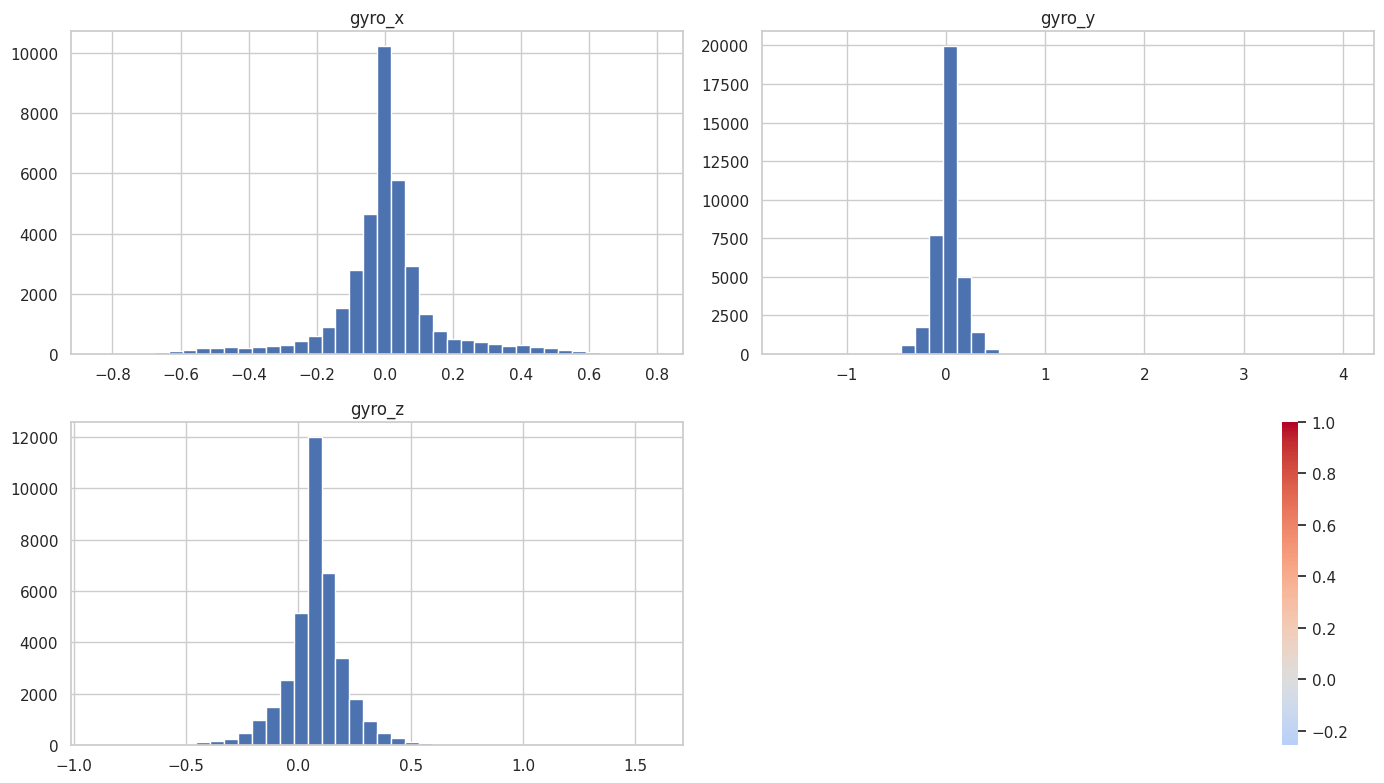

In [5]:
display(imu_df.describe().T)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
imu_df[["acc_x", "acc_y", "acc_z"]].hist(ax=axes[0, 0], bins=40)
axes[0, 0].set_title("Accel Histograms")

imu_df[["gyro_x", "gyro_y", "gyro_z"]].hist(ax=axes[0, 1], bins=40)
axes[0, 1].set_title("Gyro Histograms")

sns.boxplot(data=imu_df[["acc_x", "acc_y", "acc_z"]], ax=axes[1, 0])
axes[1, 0].set_title("Accel Boxplot")

corr = imu_df[["gyro_x", "gyro_y", "gyro_z", "acc_x", "acc_y", "acc_z"]].corr()
sns.heatmap(corr, ax=axes[1, 1], cmap="coolwarm", center=0, annot=False)
axes[1, 1].set_title("IMU Correlation")

plt.tight_layout()
plt.show()

## 6. Build Feature Transformations

In [6]:
def build_windows(imu: pd.DataFrame, gt_interp: pd.DataFrame, window_size=200, stride=20, horizon=200):
    imu_feat = imu[["gyro_x", "gyro_y", "gyro_z", "acc_x", "acc_y", "acc_z"]].to_numpy(dtype=np.float32)
    pos = gt_interp[["p_x", "p_y", "p_z"]].to_numpy(dtype=np.float32)

    X_list, y_list = [], []
    max_start = len(imu_feat) - window_size - horizon
    for start in range(0, max_start + 1, stride):
        end = start + window_size
        target_idx = end + horizon - 1
        X_list.append(imu_feat[start:end])
        y_list.append(pos[target_idx] - pos[end - 1])

    if not X_list:
        return np.empty((0, window_size, 6), dtype=np.float32), np.empty((0, 3), dtype=np.float32)

    return np.stack(X_list, axis=0), np.stack(y_list, axis=0)


def process_sequence(seq_path: Path):
    mav0 = seq_path / "mav0"
    gt_path = mav0 / "state_groundtruth_estimate0" / "data.csv"
    imu_path = mav0 / "imu0" / "data.csv"

    if not imu_path.exists() or not gt_path.exists():
        return {"sequence": seq_path.name, "status": "skipped_missing_files", "samples": 0}

    imu = load_imu_csv(mav0)
    gt = load_gt_csv(mav0)
    imu, gt = clean_and_validate(imu, gt)
    gt_interp = interpolate_gt_to_imu(imu, gt)
    X, y = build_windows(imu, gt_interp, WINDOW_SIZE, STRIDE, HORIZON)

    np.save(SEQUENCE_OUTPUT_DIR / f"{seq_path.name}_X.npy", X)
    np.save(SEQUENCE_OUTPUT_DIR / f"{seq_path.name}_y.npy", y)

    meta = {
        "sequence": seq_path.name,
        "status": "ok",
        "imu_rows": int(len(imu)),
        "gt_rows": int(len(gt)),
        "samples": int(len(X)),
        "window_size": int(WINDOW_SIZE),
        "stride": int(STRIDE),
        "horizon": int(HORIZON),
    }
    with open(SEQUENCE_OUTPUT_DIR / f"{seq_path.name}_meta.json", "w", encoding="utf-8") as f:
        json.dump(meta, f, indent=2)
    return meta


records = []
for seq_path in sequence_paths:
    rec = process_sequence(seq_path)
    records.append(rec)
    print(f"{rec['sequence']}: {rec['status']} ({rec['samples']} samples)")

manifest_df = pd.DataFrame(records).sort_values("sequence").reset_index(drop=True)
manifest_df.to_csv(SEQUENCE_OUTPUT_DIR / "manifest.csv", index=False)
manifest_df.head()

MH_01_easy: ok (1822 samples)
MH_02_easy: ok (1501 samples)
MH_03_medium: ok (1331 samples)
MH_04_difficult: ok (997 samples)
MH_05_difficult: ok (1117 samples)
V1_03_difficult: ok (1056 samples)
V2_01_easy: ok (1121 samples)
V2_02_medium: ok (1155 samples)
V2_03_difficult: ok (1149 samples)


,sequence,status,imu_rows,gt_rows,samples,window_size,stride,horizon
0,MH_01_easy,ok,36820,36382,1822,200,20,200
1,MH_02_easy,ok,30400,29993,1501,200,20,200
2,MH_03_medium,ok,27008,26302,1331,200,20,200
3,MH_04_difficult,ok,20320,19753,997,200,20,200
4,MH_05_difficult,ok,22721,22212,1117,200,20,200


## 7. Split Data for Training and Testing

In [7]:
ok_df = manifest_df[(manifest_df["status"] == "ok") & (manifest_df["samples"] > 0)].copy()
sequences = ok_df["sequence"].tolist()

if len(sequences) == 0:
    raise ValueError("No valid processed sequences found")


def load_split_arrays(split_sequences):
    if len(split_sequences) == 0:
        return (
            np.empty((0, WINDOW_SIZE, 6), dtype=np.float32),
            np.empty((0, 3), dtype=np.float32),
            np.empty((0,), dtype=object),
        )

    X_parts, y_parts, seq_col = [], [], []
    for seq in split_sequences:
        x = np.load(SEQUENCE_OUTPUT_DIR / f"{seq}_X.npy")
        y = np.load(SEQUENCE_OUTPUT_DIR / f"{seq}_y.npy")
        X_parts.append(x)
        y_parts.append(y)
        seq_col.extend([seq] * len(x))
    return np.concatenate(X_parts, axis=0), np.concatenate(y_parts, axis=0), np.array(seq_col)


if len(sequences) >= 3:
    split_mode = "sequence_level"
    train_seqs, test_seqs = train_test_split(sequences, test_size=0.2, random_state=SEED)
    train_seqs, val_seqs = train_test_split(train_seqs, test_size=0.2, random_state=SEED)

    X_train, y_train, seq_train = load_split_arrays(train_seqs)
    X_val, y_val, seq_val = load_split_arrays(val_seqs)
    X_test, y_test, seq_test = load_split_arrays(test_seqs)
else:
    split_mode = "sample_level_fallback"
    train_seqs, val_seqs, test_seqs = sequences, [], []

    X_all, y_all, seq_all = load_split_arrays(sequences)

    X_train, X_tmp, y_train, y_tmp = train_test_split(
        X_all, y_all, test_size=0.3, random_state=SEED
    )
    X_val, X_test, y_val, y_test = train_test_split(
        X_tmp, y_tmp, test_size=0.5, random_state=SEED
    )
    seq_train = np.array(["sample_split"] * len(X_train))
    seq_val = np.array(["sample_split"] * len(X_val))
    seq_test = np.array(["sample_split"] * len(X_test))

for name, items in [("train", train_seqs), ("val", val_seqs), ("test", test_seqs)]:
    with open(SPLIT_DIR / f"{name}_sequences.txt", "w", encoding="utf-8") as f:
        if len(items) > 0:
            f.write("\n".join(items) + "\n")

print("Split mode:", split_mode)
print("Sequence split sizes:", len(train_seqs), len(val_seqs), len(test_seqs))
print("Train:", X_train.shape, y_train.shape)
print("Val:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

Split mode: sequence_level
Sequence split sizes: 5 2 2
Train: (5715, 200, 6) (5715, 3)
Val: (2878, 200, 6) (2878, 3)
Test: (2656, 200, 6) (2656, 3)


## 8. Train Baseline Model

In [8]:
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_val_flat = X_val.reshape(X_val.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

baseline_model = Pipeline(
    [
        ("scaler", StandardScaler()),
        ("reg", Ridge(alpha=1.0, random_state=SEED)),
    ]
)

baseline_model.fit(X_train_flat, y_train)
val_pred = baseline_model.predict(X_val_flat)
test_pred = baseline_model.predict(X_test_flat)

print("Baseline model trained.")
print("Validation predictions shape:", val_pred.shape)
print("Test predictions shape:", test_pred.shape)

Baseline model trained.
Validation predictions shape: (2878, 3)
Test predictions shape: (2656, 3)


## 9. Evaluate Model with Metrics

,split,mse,rmse,mae,r2
0,val,0.256414,0.506374,0.365528,-1.000370
1,test,0.231000,0.480625,0.335143,-0.523284


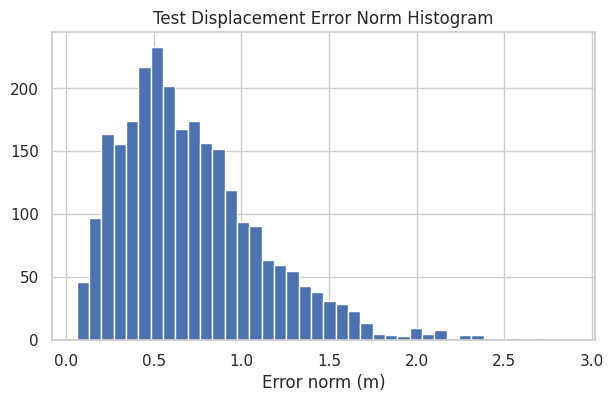

In [9]:
def regression_metrics(y_true, y_pred, name):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return {"split": name, "mse": mse, "rmse": rmse, "mae": mae, "r2": r2}

metrics_rows = [
    regression_metrics(y_val, val_pred, "val"),
    regression_metrics(y_test, test_pred, "test"),
]
metrics_df = pd.DataFrame(metrics_rows)
display(metrics_df)

err = y_test - test_pred
fig, ax = plt.subplots(1, 1, figsize=(7, 4))
ax.hist(np.linalg.norm(err, axis=1), bins=40)
ax.set_title("Test Displacement Error Norm Histogram")
ax.set_xlabel("Error norm (m)")
plt.show()

## 10. Tune Hyperparameters

In [10]:
param_grid = {"reg__alpha": [0.1, 1.0, 10.0]}
search = GridSearchCV(
    estimator=Pipeline([("scaler", StandardScaler()), ("reg", Ridge(random_state=SEED))]),
    param_grid=param_grid,
    scoring="neg_mean_squared_error",
    cv=3,
    n_jobs=-1,
)
search.fit(X_train_flat, y_train)

best_model = search.best_estimator_
best_val_pred = best_model.predict(X_val_flat)

print("Best params:", search.best_params_)
print("Best CV score (neg MSE):", search.best_score_)
print("Best model val RMSE:", np.sqrt(mean_squared_error(y_val, best_val_pred)))

Best params: {'reg__alpha': 10.0}
Best CV score (neg MSE): -0.37561845779418945
Best model val RMSE: 0.4880127435568054


## 11. Save Model and Outputs

In [11]:
best_test_pred = best_model.predict(X_test_flat)

metrics_final = pd.DataFrame([
    regression_metrics(y_train, best_model.predict(X_train_flat), "train"),
    regression_metrics(y_val, best_model.predict(X_val_flat), "val"),
    regression_metrics(y_test, best_test_pred, "test"),
])
metrics_final.to_csv(SPLIT_DIR / "metrics_summary.csv", index=False)

joblib.dump(best_model, MODEL_DIR / "ridge_displacement_model.joblib")

split_manifest = {
    "train_sequences": train_seqs,
    "val_sequences": val_seqs,
    "test_sequences": test_seqs,
    "split_mode": split_mode,
    "seed": SEED,
    "window_size": WINDOW_SIZE,
    "stride": STRIDE,
    "horizon": HORIZON,
}
with open(SPLIT_DIR / "split_manifest.json", "w", encoding="utf-8") as f:
    json.dump(split_manifest, f, indent=2)

metrics_final

,split,mse,rmse,mae,r2
0,train,0.209722,0.457955,0.319293,0.325032
1,val,0.238156,0.488013,0.353636,-0.861639
2,test,0.218002,0.466907,0.325448,-0.437559


## 12. Run Automated Checks and Assertions

In [12]:
assert X_train.ndim == 3 and X_train.shape[2] == 6
assert y_train.ndim == 2 and y_train.shape[1] == 3
assert len(X_train) > 0 and len(X_val) > 0 and len(X_test) > 0

if len(val_seqs) > 0 and len(test_seqs) > 0:
    assert set(train_seqs).isdisjoint(val_seqs)
    assert set(train_seqs).isdisjoint(test_seqs)
    assert set(val_seqs).isdisjoint(test_seqs)

assert (SPLIT_DIR / "split_manifest.json").exists()
assert (SPLIT_DIR / "metrics_summary.csv").exists()
assert (MODEL_DIR / "ridge_displacement_model.joblib").exists()

print("All automated checks passed.")

# Final verification cell
example_seq = train_seqs[0]
example_X = np.load(SEQUENCE_OUTPUT_DIR / f"{example_seq}_X.npy")
example_y = np.load(SEQUENCE_OUTPUT_DIR / f"{example_seq}_y.npy")
print("Example sequence:", example_seq)
print("Example X shape:", example_X.shape)
print("Example y shape:", example_y.shape)
print("Split mode:", split_mode)
print("Split counts:", {"train": len(train_seqs), "val": len(val_seqs), "test": len(test_seqs)})

All automated checks passed.
Example sequence: MH_04_difficult
Example X shape: (997, 200, 6)
Example y shape: (997, 3)
Split mode: sequence_level
Split counts: {'train': 5, 'val': 2, 'test': 2}


In [13]:
# Optional: minimal cross-attention-ready model skeleton (PyTorch)
# This cell defines model classes only; train loop can be added after validating data volumes.

import torch
import torch.nn as nn


class TinyIMUEncoder(nn.Module):
    def __init__(self, in_dim=6, hid=128):
        super().__init__()
        self.rnn = nn.GRU(in_dim, hid, batch_first=True, bidirectional=True)
        self.proj = nn.Linear(hid * 2, hid)

    def forward(self, x):  # x: [B, T, 6]
        h, _ = self.rnn(x)
        return self.proj(h)  # [B, T, H]


class TinyImageEncoder(nn.Module):
    def __init__(self, out_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 16, 3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(16, 32, 3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 64, 3, stride=2, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1)),
        )
        self.fc = nn.Linear(64, out_dim)

    def forward(self, img):  # [B, 1, H, W]
        z = self.net(img).flatten(1)
        return self.fc(z).unsqueeze(1)  # [B, 1, H]


class IMUGuidedCrossAttentionRegressor(nn.Module):
    def __init__(self, hid=128, n_heads=4):
        super().__init__()
        self.imu_enc = TinyIMUEncoder(in_dim=6, hid=hid)
        self.img_enc = TinyImageEncoder(out_dim=hid)
        self.cross_attn = nn.MultiheadAttention(embed_dim=hid, num_heads=n_heads, batch_first=True)
        self.head = nn.Sequential(nn.Linear(hid, hid), nn.ReLU(), nn.Linear(hid, 3))

    def forward(self, x_imu, x_img):
        imu_tokens = self.imu_enc(x_imu)         # [B, T, H]
        img_token = self.img_enc(x_img)          # [B, 1, H]
        fused, _ = self.cross_attn(query=img_token, key=imu_tokens, value=imu_tokens)
        return self.head(fused.squeeze(1))       # [B, 3]


print("Defined IMU-guided cross-attention model skeleton.")
print("Next step: build DataLoader from processed_data/multimodal and train.")

Defined IMU-guided cross-attention model skeleton.
Next step: build DataLoader from processed_data/multimodal and train.


In [15]:
import cv2
import numpy as np
import pandas as pd

TARGET_IMG_SIZE = (160, 120)
IMAGE_STEP = 10

def load_cam0_index(mav0_dir):
    cam_idx = pd.read_csv(
        mav0_dir / "cam0" / "data.csv",
        comment="#",
        header=None,
        names=["timestamp_ns", "filename"],
    )
    cam_idx["timestamp_ns"] = cam_idx["timestamp_ns"].astype(np.int64)
    return cam_idx.sort_values("timestamp_ns").reset_index(drop=True)

def nearest_index(sorted_ts, t_ns):
    pos = np.searchsorted(sorted_ts, t_ns)
    if pos <= 0:
        return 0
    if pos >= len(sorted_ts):
        return len(sorted_ts) - 1
    left, right = pos - 1, pos
    return left if abs(sorted_ts[left] - t_ns) <= abs(sorted_ts[right] - t_ns) else right

def make_multimodal_samples_for_sequence(seq_path, max_images=None):
    mav0 = seq_path / "mav0"
    imu = load_imu_csv(mav0)
    gt = load_gt_csv(mav0)
    imu, gt = clean_and_validate(imu, gt)
    gt_interp = interpolate_gt_to_imu(imu, gt)
    cam_idx = load_cam0_index(mav0)

    imu_ts = imu["timestamp_ns"].to_numpy(dtype=np.int64)
    imu_feat = imu[["gyro_x","gyro_y","gyro_z","acc_x","acc_y","acc_z"]].to_numpy(dtype=np.float32)
    pos = gt_interp[["p_x","p_y","p_z"]].to_numpy(dtype=np.float32)

    rows = cam_idx.iloc[::IMAGE_STEP].reset_index(drop=True)
    if max_images is not None:
        rows = rows.iloc[:max_images]

    X_imu, X_img, y_disp, valid_ts = [], [], [], []

    for _, r in rows.iterrows():
        t_cam = int(r["timestamp_ns"])
        i = nearest_index(imu_ts, t_cam)

        start = i - WINDOW_SIZE + 1
        target_idx = i + HORIZON
        if start < 0 or target_idx >= len(imu_feat):
            continue

        img_path = mav0 / "cam0" / "data" / str(r["filename"])
        img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
        if img is None:
            continue
        img = cv2.resize(img, TARGET_IMG_SIZE, interpolation=cv2.INTER_AREA)
        img = (img.astype(np.float32) / 255.0)[None, :, :]

        X_imu.append(imu_feat[start:i+1])
        X_img.append(img)
        y_disp.append(pos[target_idx] - pos[i])
        valid_ts.append(t_cam)

    if len(X_imu) == 0:
        return None

    return {
        "X_imu": np.stack(X_imu).astype(np.float32),
        "X_img": np.stack(X_img).astype(np.float32),
        "y": np.stack(y_disp).astype(np.float32),
        "timestamp_ns": np.array(valid_ts, dtype=np.int64),
    }

print("helper_defined:", "make_multimodal_samples_for_sequence" in globals())

helper_defined: True


In [16]:
MULTI_DIR = PROCESSED_ROOT / "multimodal"
MULTI_DIR.mkdir(parents=True, exist_ok=True)

multimodal_records = []
for seq_path in sequence_paths:
    out = make_multimodal_samples_for_sequence(seq_path, max_images=1200)
    if out is None:
        multimodal_records.append({"sequence": seq_path.name, "status": "no_samples", "samples": 0})
        print(seq_path.name, "-> no samples")
        continue

    np.save(MULTI_DIR / f"{seq_path.name}_X_imu.npy", out["X_imu"])
    np.save(MULTI_DIR / f"{seq_path.name}_X_img.npy", out["X_img"])
    np.save(MULTI_DIR / f"{seq_path.name}_y.npy", out["y"])

    meta = {
        "sequence": seq_path.name,
        "status": "ok",
        "samples": int(out["X_imu"].shape[0]),
        "imu_shape": list(out["X_imu"].shape),
        "img_shape": list(out["X_img"].shape),
        "target_shape": list(out["y"].shape),
    }
    with open(MULTI_DIR / f"{seq_path.name}_meta.json", "w", encoding="utf-8") as f:
        json.dump(meta, f, indent=2)

    multimodal_records.append(meta)
    print(seq_path.name, "->", out["X_imu"].shape, out["X_img"].shape, out["y"].shape)

multi_manifest = pd.DataFrame(multimodal_records)
multi_manifest.to_csv(MULTI_DIR / "manifest.csv", index=False)
multi_manifest

MH_01_easy -> (365, 200, 6) (365, 1, 120, 160) (365, 3)
MH_02_easy -> (300, 200, 6) (300, 1, 120, 160) (300, 3)
MH_03_medium -> (266, 200, 6) (266, 1, 120, 160) (266, 3)
MH_04_difficult -> (199, 200, 6) (199, 1, 120, 160) (199, 3)
MH_05_difficult -> (223, 200, 6) (223, 1, 120, 160) (223, 3)
V1_03_difficult -> (211, 200, 6) (211, 1, 120, 160) (211, 3)
V2_01_easy -> (224, 200, 6) (224, 1, 120, 160) (224, 3)
V2_02_medium -> (231, 200, 6) (231, 1, 120, 160) (231, 3)
V2_03_difficult -> (189, 200, 6) (189, 1, 120, 160) (189, 3)


,sequence,status,samples,imu_shape,img_shape,target_shape
0,MH_01_easy,ok,365,"[365, 200, 6]","[365, 1, 120, 160]","[365, 3]"
1,MH_02_easy,ok,300,"[300, 200, 6]","[300, 1, 120, 160]","[300, 3]"
2,MH_03_medium,ok,266,"[266, 200, 6]","[266, 1, 120, 160]","[266, 3]"
3,MH_04_difficult,ok,199,"[199, 200, 6]","[199, 1, 120, 160]","[199, 3]"
4,MH_05_difficult,ok,223,"[223, 200, 6]","[223, 1, 120, 160]","[223, 3]"
5,V1_03_difficult,ok,211,"[211, 200, 6]","[211, 1, 120, 160]","[211, 3]"
6,V2_01_easy,ok,224,"[224, 200, 6]","[224, 1, 120, 160]","[224, 3]"
7,V2_02_medium,ok,231,"[231, 200, 6]","[231, 1, 120, 160]","[231, 3]"
8,V2_03_difficult,ok,189,"[189, 200, 6]","[189, 1, 120, 160]","[189, 3]"


In [17]:
import cv2

TARGET_IMG_SIZE = (160, 120)  # width, height
IMAGE_STEP = 10               # sample every Nth camera frame to control dataset size


def load_cam0_index(mav0_dir: Path) -> pd.DataFrame:
    cam_idx = pd.read_csv(
        mav0_dir / "cam0" / "data.csv",
        comment="#",
        header=None,
        names=["timestamp_ns", "filename"],
    )
    cam_idx["timestamp_ns"] = cam_idx["timestamp_ns"].astype(np.int64)
    return cam_idx.sort_values("timestamp_ns").reset_index(drop=True)


def nearest_index(sorted_ts: np.ndarray, t_ns: int) -> int:
    pos = np.searchsorted(sorted_ts, t_ns)
    if pos <= 0:
        return 0
    if pos >= len(sorted_ts):
        return len(sorted_ts) - 1
    left, right = pos - 1, pos
    return left if abs(sorted_ts[left] - t_ns) <= abs(sorted_ts[right] - t_ns) else right


def make_multimodal_samples_for_sequence(seq_path: Path, max_images=None):
    mav0 = seq_path / "mav0"
    imu = load_imu_csv(mav0)
    gt = load_gt_csv(mav0)
    imu, gt = clean_and_validate(imu, gt)
    gt_interp = interpolate_gt_to_imu(imu, gt)
    cam_idx = load_cam0_index(mav0)

    imu_ts = imu["timestamp_ns"].to_numpy(dtype=np.int64)
    imu_feat = imu[["gyro_x", "gyro_y", "gyro_z", "acc_x", "acc_y", "acc_z"]].to_numpy(dtype=np.float32)
    pos = gt_interp[["p_x", "p_y", "p_z"]].to_numpy(dtype=np.float32)

    rows = cam_idx.iloc[::IMAGE_STEP].reset_index(drop=True)
    if max_images is not None:
        rows = rows.iloc[:max_images]

    X_imu, X_img, y_disp, valid_ts = [], [], [], []

    for _, r in rows.iterrows():
        t_cam = int(r["timestamp_ns"])
        i = nearest_index(imu_ts, t_cam)

        start = i - WINDOW_SIZE + 1
        end = i + 1
        target_idx = i + HORIZON

        if start < 0 or target_idx >= len(imu_feat):
            continue

        img_path = mav0 / "cam0" / "data" / str(r["filename"])
        img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
        if img is None:
            continue
        img = cv2.resize(img, TARGET_IMG_SIZE, interpolation=cv2.INTER_AREA)
        img = (img.astype(np.float32) / 255.0)[None, :, :]  # [1, H, W]

        x_imu = imu_feat[start:end]  # [T, 6]
        disp = pos[target_idx] - pos[i]

        X_imu.append(x_imu)
        X_img.append(img)
        y_disp.append(disp)
        valid_ts.append(t_cam)

    if len(X_imu) == 0:
        return None

    return {
        "X_imu": np.stack(X_imu, axis=0).astype(np.float32),
        "X_img": np.stack(X_img, axis=0).astype(np.float32),
        "y": np.stack(y_disp, axis=0).astype(np.float32),
        "timestamp_ns": np.array(valid_ts, dtype=np.int64),
    }

## 13. Multimodal IMU + Image Pipeline (Cross-Attention Ready)

The earlier sections are IMU-only. This section prepares synchronized IMU windows and camera frames (cam0) for a paper-style IMU-guided visual fusion approach.

## 14. IMU + Camera Training Pipeline from the Document

This section implements the document specifications:
- EuRoC camera 20 Hz and IMU 200 Hz pairing
- Last 100 IMU readings per camera frame
- Target displacement between consecutive camera frames
- Two models: concat baseline and IMU-guided cross-attention
- MSE loss + Adam optimizer
- Frozen image backbone with trainable fusion/prediction layers

In [18]:
# Uncomment if needed
# %pip install torch torchvision opencv-python

import cv2
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

Using device: cuda


In [19]:
IMU_WINDOW = 100
IMG_SIZE = (224, 224)
BATCH_SIZE = 64
EPOCHS = 8
LR = 1e-3


def build_doc_samples_for_sequence(seq_path: Path, low_texture=False):
    mav0 = seq_path / "mav0"
    imu = load_imu_csv(mav0)
    gt = load_gt_csv(mav0)
    imu, gt = clean_and_validate(imu, gt)
    gt_interp = interpolate_gt_to_imu(imu, gt)
    cam_idx = load_cam0_index(mav0)

    imu_ts = imu["timestamp_ns"].to_numpy(dtype=np.int64)
    imu_feat = imu[["gyro_x", "gyro_y", "gyro_z", "acc_x", "acc_y", "acc_z"]].to_numpy(dtype=np.float32)
    pos = gt_interp[["p_x", "p_y", "p_z"]].to_numpy(dtype=np.float32)

    X_imu, X_img, y = [], [], []

    cam_rows = cam_idx.reset_index(drop=True)
    for i in range(len(cam_rows) - 1):
        t0 = int(cam_rows.iloc[i]["timestamp_ns"])
        t1 = int(cam_rows.iloc[i + 1]["timestamp_ns"])
        img_file = str(cam_rows.iloc[i]["filename"])

        imu_i = nearest_index(imu_ts, t0)
        imu_start = imu_i - IMU_WINDOW + 1
        if imu_start < 0:
            continue

        imu_window = imu_feat[imu_start:imu_i + 1]

        gt_i0 = nearest_index(imu_ts, t0)
        gt_i1 = nearest_index(imu_ts, t1)
        disp = pos[gt_i1] - pos[gt_i0]

        img_path = mav0 / "cam0" / "data" / img_file
        img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
        if img is None:
            continue
        img = cv2.resize(img, IMG_SIZE, interpolation=cv2.INTER_AREA)

        if low_texture:
            img = cv2.GaussianBlur(img, (7, 7), 0)
            img = cv2.equalizeHist(img)

        img = img.astype(np.float32) / 255.0
        img = np.expand_dims(img, axis=0)

        X_imu.append(imu_window)
        X_img.append(img)
        y.append(disp)

    if len(X_imu) == 0:
        return None

    return {
        "X_imu": np.asarray(X_imu, dtype=np.float32),
        "X_img": np.asarray(X_img, dtype=np.float32),
        "y": np.asarray(y, dtype=np.float32),
    }


class IMUCameraDataset(Dataset):
    def __init__(self, X_imu, X_img, y):
        self.X_imu = torch.from_numpy(X_imu)
        self.X_img = torch.from_numpy(X_img)
        self.y = torch.from_numpy(y)

    def __len__(self):
        return self.X_imu.shape[0]

    def __getitem__(self, idx):
        return self.X_imu[idx], self.X_img[idx], self.y[idx]

In [20]:
class IMUEncoder(nn.Module):
    def __init__(self, in_dim=6, hidden_dim=128, out_dim=256):
        super().__init__()
        self.lstm = nn.LSTM(in_dim, hidden_dim, num_layers=1, batch_first=True, bidirectional=True)
        self.proj = nn.Linear(hidden_dim * 2, out_dim)

    def forward(self, x):
        h, _ = self.lstm(x)
        return self.proj(h[:, -1])


class MobileNetPatchEncoder(nn.Module):
    def __init__(self, out_dim=256, freeze_backbone=True):
        super().__init__()
        weights = models.MobileNet_V3_Small_Weights.DEFAULT
        base = models.mobilenet_v3_small(weights=weights)
        self.features = base.features
        self.proj = nn.Linear(576, out_dim)
        self.global_proj = nn.Linear(576, out_dim)

        if freeze_backbone:
            for p in self.features.parameters():
                p.requires_grad = False

    def forward(self, img):
        x = img.repeat(1, 3, 1, 1)
        fmap = self.features(x)
        fmap = nn.functional.adaptive_avg_pool2d(fmap, (7, 7))
        B, C, H, W = fmap.shape
        patches = fmap.permute(0, 2, 3, 1).reshape(B, H * W, C)
        patch_tokens = self.proj(patches)
        global_token = self.global_proj(fmap.mean(dim=(2, 3)))
        return patch_tokens, global_token


class ConcatBaselineModel(nn.Module):
    def __init__(self, hid=256):
        super().__init__()
        self.imu = IMUEncoder(out_dim=hid)
        self.img = MobileNetPatchEncoder(out_dim=hid, freeze_backbone=True)
        self.head = nn.Sequential(nn.Linear(hid * 2, 64), nn.ReLU(), nn.Linear(64, 64), nn.ReLU(), nn.Linear(64, 3))

    def forward(self, x_imu, x_img):
        imu_vec = self.imu(x_imu)
        _, img_global = self.img(x_img)
        fused = torch.cat([imu_vec, img_global], dim=-1)
        return self.head(fused)


class IMUGuidedCrossAttentionModel(nn.Module):
    def __init__(self, hid=256, heads=4):
        super().__init__()
        self.imu = IMUEncoder(out_dim=hid)
        self.img = MobileNetPatchEncoder(out_dim=hid, freeze_backbone=True)
        self.attn = nn.MultiheadAttention(embed_dim=hid, num_heads=heads, batch_first=True)
        self.head = nn.Sequential(nn.Linear(hid, 64), nn.ReLU(), nn.Linear(64, 64), nn.ReLU(), nn.Linear(64, 3))

    def forward(self, x_imu, x_img, return_attn=False):
        q = self.imu(x_imu).unsqueeze(1)
        kv, _ = self.img(x_img)
        attn_out, attn_weights = self.attn(q, kv, kv, need_weights=True)
        out = self.head(attn_out.squeeze(1))
        if return_attn:
            return out, attn_weights
        return out

In [22]:
def assemble_splits_doc(sequence_paths):
    seq_names = [p.name for p in sequence_paths]
    if len(seq_names) == 0:
        raise ValueError("No sequence folders found")

    if len(seq_names) >= 3:
        tr, te = train_test_split(seq_names, test_size=0.25, random_state=SEED)
        tr, va = train_test_split(tr, test_size=0.25, random_state=SEED)
    else:
        tr, va, te = seq_names, seq_names, seq_names

    name_to_path = {p.name: p for p in sequence_paths}

    def build(split_names, low_texture=False):
        X_imu_all, X_img_all, y_all = [], [], []
        for n in split_names:
            out = build_doc_samples_for_sequence(name_to_path[n], low_texture=low_texture)
            if out is None:
                continue
            X_imu_all.append(out["X_imu"])
            X_img_all.append(out["X_img"])
            y_all.append(out["y"])

        if len(X_imu_all) == 0:
            return None

        return (
            np.concatenate(X_imu_all, axis=0),
            np.concatenate(X_img_all, axis=0),
            np.concatenate(y_all, axis=0),
        )

    train_pack = build(tr, low_texture=False)
    val_pack = build(va, low_texture=False)
    test_pack = build(te, low_texture=False)
    test_lowtex_pack = build(te, low_texture=True)

    return tr, va, te, train_pack, val_pack, test_pack, test_lowtex_pack


train_seq, val_seq, test_seq, train_pack, val_pack, test_pack, test_lowtex_pack = assemble_splits_doc(sequence_paths)

assert train_pack is not None and val_pack is not None and test_pack is not None

train_ds = IMUCameraDataset(*train_pack)
val_ds = IMUCameraDataset(*val_pack)
test_ds = IMUCameraDataset(*test_pack)

test_lowtex_ds = IMUCameraDataset(*test_lowtex_pack) if test_lowtex_pack is not None else None

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_lowtex_loader = DataLoader(test_lowtex_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0) if test_lowtex_ds else None

print("Train seq:", train_seq)
print("Val seq:", val_seq)
print("Test seq:", test_seq)
print("Samples train/val/test:", len(train_ds), len(val_ds), len(test_ds))
if test_lowtex_ds:
    print("Samples low-texture test:", len(test_lowtex_ds))

Train seq: ['V2_01_easy', 'MH_03_medium', 'MH_04_difficult', 'MH_05_difficult']
Val seq: ['MH_01_easy', 'V2_03_difficult']
Test seq: ['V2_02_medium', 'MH_02_easy', 'V1_03_difficult']
Samples train/val/test: 9240 5581 7504
Samples low-texture test: 7504


In [23]:
def run_epoch(model, loader, optimizer=None):
    train_mode = optimizer is not None
    model.train(train_mode)
    criterion = nn.MSELoss()

    total_loss = 0.0
    n = 0
    all_y, all_pred = [], []

    for x_imu, x_img, y in loader:
        x_imu = x_imu.to(DEVICE)
        x_img = x_img.to(DEVICE)
        y = y.to(DEVICE)

        pred = model(x_imu, x_img)
        loss = criterion(pred, y)

        if train_mode:
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        bs = y.shape[0]
        total_loss += loss.item() * bs
        n += bs
        all_y.append(y.detach().cpu().numpy())
        all_pred.append(pred.detach().cpu().numpy())

    y_true = np.concatenate(all_y, axis=0)
    y_pred = np.concatenate(all_pred, axis=0)
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))

    return total_loss / max(1, n), rmse


def train_model(model, train_loader, val_loader, epochs=EPOCHS, lr=LR):
    model = model.to(DEVICE)
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)

    hist = []
    best_val = float("inf")
    best_state = None

    for ep in range(1, epochs + 1):
        tr_loss, tr_rmse = run_epoch(model, train_loader, optimizer)
        va_loss, va_rmse = run_epoch(model, val_loader, optimizer=None)
        hist.append({"epoch": ep, "train_loss": tr_loss, "train_rmse": tr_rmse, "val_loss": va_loss, "val_rmse": va_rmse})
        print(f"Epoch {ep:02d} | train_loss={tr_loss:.4f} val_loss={va_loss:.4f} | train_rmse={tr_rmse:.4f} val_rmse={va_rmse:.4f}")

        if va_loss < best_val:
            best_val = va_loss
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    if best_state is not None:
        model.load_state_dict(best_state)

    return model, pd.DataFrame(hist)


baseline_model = ConcatBaselineModel()
attn_model = IMUGuidedCrossAttentionModel()

baseline_model, baseline_hist = train_model(baseline_model, train_loader, val_loader)
attn_model, attn_hist = train_model(attn_model, train_loader, val_loader)

baseline_hist.tail(), attn_hist.tail()

Epoch 01 | train_loss=0.0008 val_loss=0.0009 | train_rmse=0.0279 val_rmse=0.0299
Epoch 02 | train_loss=0.0003 val_loss=0.0008 | train_rmse=0.0185 val_rmse=0.0277
Epoch 03 | train_loss=0.0002 val_loss=0.0010 | train_rmse=0.0153 val_rmse=0.0322
Epoch 04 | train_loss=0.0002 val_loss=0.0008 | train_rmse=0.0134 val_rmse=0.0282
Epoch 05 | train_loss=0.0002 val_loss=0.0009 | train_rmse=0.0123 val_rmse=0.0298
Epoch 06 | train_loss=0.0001 val_loss=0.0010 | train_rmse=0.0108 val_rmse=0.0324
Epoch 07 | train_loss=0.0001 val_loss=0.0008 | train_rmse=0.0102 val_rmse=0.0274
Epoch 08 | train_loss=0.0001 val_loss=0.0007 | train_rmse=0.0096 val_rmse=0.0263
Epoch 01 | train_loss=0.0007 val_loss=0.0010 | train_rmse=0.0263 val_rmse=0.0318
Epoch 02 | train_loss=0.0002 val_loss=0.0007 | train_rmse=0.0145 val_rmse=0.0257
Epoch 03 | train_loss=0.0001 val_loss=0.0006 | train_rmse=0.0115 val_rmse=0.0252
Epoch 04 | train_loss=0.0001 val_loss=0.0008 | train_rmse=0.0098 val_rmse=0.0290
Epoch 05 | train_loss=0.0001

(   epoch  train_loss  train_rmse  val_loss  val_rmse
 3      4    0.000180    0.013415  0.000795  0.028194
 4      5    0.000150    0.012259  0.000886  0.029764
 5      6    0.000117    0.010828  0.001047  0.032362
 6      7    0.000105    0.010232  0.000753  0.027444
 7      8    0.000093    0.009643  0.000690  0.026262,
    epoch  train_loss  train_rmse  val_loss  val_rmse
 3      4    0.000096    0.009794  0.000840  0.028986
 4      5    0.000075    0.008649  0.000831  0.028828
 5      6    0.000063    0.007960  0.000850  0.029155
 6      7    0.000054    0.007343  0.000858  0.029287
 7      8    0.000052    0.007204  0.000820  0.028633)

In [24]:
def evaluate_model(model, loader, name):
    loss, rmse = run_epoch(model, loader, optimizer=None)
    return {"split": name, "mse": loss, "rmse": rmse}

rows = []
rows.append({"model": "concat", **evaluate_model(baseline_model, test_loader, "normal")})
rows.append({"model": "attention", **evaluate_model(attn_model, test_loader, "normal")})

if test_lowtex_loader is not None:
    rows.append({"model": "concat", **evaluate_model(baseline_model, test_lowtex_loader, "low_texture")})
    rows.append({"model": "attention", **evaluate_model(attn_model, test_lowtex_loader, "low_texture")})

doc_eval_df = pd.DataFrame(rows)
display(doc_eval_df)

# Persist results
DOC_DIR = PROCESSED_ROOT / "doc_style_training"
DOC_DIR.mkdir(parents=True, exist_ok=True)

doc_eval_df.to_csv(DOC_DIR / "doc_style_eval.csv", index=False)
baseline_hist.to_csv(DOC_DIR / "concat_history.csv", index=False)
attn_hist.to_csv(DOC_DIR / "attention_history.csv", index=False)
torch.save(baseline_model.state_dict(), DOC_DIR / "concat_model.pt")
torch.save(attn_model.state_dict(), DOC_DIR / "attention_model.pt")

print("Saved doc-style training artifacts to", DOC_DIR)

,model,split,mse,rmse
0,concat,normal,0.000554,0.023546
1,attention,normal,0.000517,0.022732
2,concat,low_texture,0.000567,0.023822
3,attention,low_texture,0.000533,0.023077


Saved doc-style training artifacts to /kaggle/working/processed_data/doc_style_training


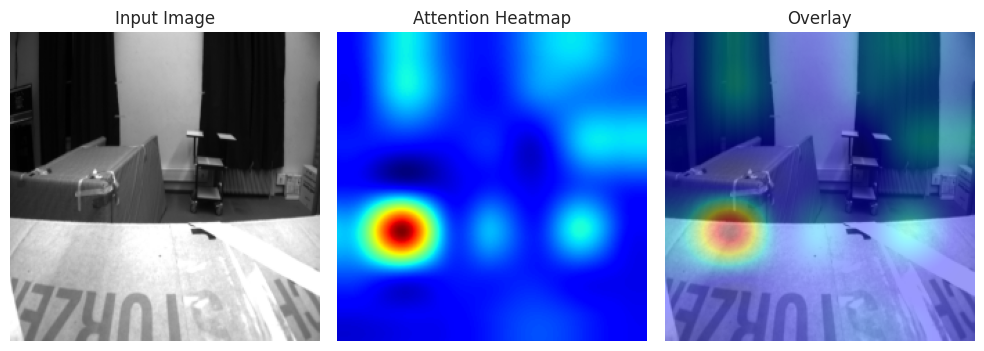

GT displacement: [0. 0. 0.]
Pred displacement: [-0.03837183 -0.02712277 -0.00051172]


In [25]:
# Attention map visualization for one test sample
sample_imu, sample_img, sample_y = test_ds[0]

attn_model.eval()
with torch.no_grad():
    pred, attn_w = attn_model(
        sample_imu.unsqueeze(0).to(DEVICE),
        sample_img.unsqueeze(0).to(DEVICE),
        return_attn=True,
    )

# attn_w shape: [B, num_queries, num_keys] => [1,1,49]
heat = attn_w[0, 0].detach().cpu().numpy().reshape(7, 7)
heat = (heat - heat.min()) / (heat.max() - heat.min() + 1e-8)

img_np = sample_img.squeeze(0).numpy()
img_show = cv2.resize(img_np, (224, 224), interpolation=cv2.INTER_AREA)
heat_show = cv2.resize(heat, (224, 224), interpolation=cv2.INTER_CUBIC)

plt.figure(figsize=(10, 4))
plt.subplot(1, 3, 1)
plt.title("Input Image")
plt.imshow(img_show, cmap="gray")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.title("Attention Heatmap")
plt.imshow(heat_show, cmap="jet")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.title("Overlay")
plt.imshow(img_show, cmap="gray")
plt.imshow(heat_show, cmap="jet", alpha=0.4)
plt.axis("off")
plt.tight_layout()
plt.show()

print("GT displacement:", sample_y.numpy())
print("Pred displacement:", pred.squeeze(0).detach().cpu().numpy())

## 15. TLIO EKF Integration Hook

This optional section prepares model displacement outputs for EKF-style trajectory smoothing.
If you want strict TLIO EKF internals, reuse TLIO tracker modules and replace network outputs with the attention model predictions.

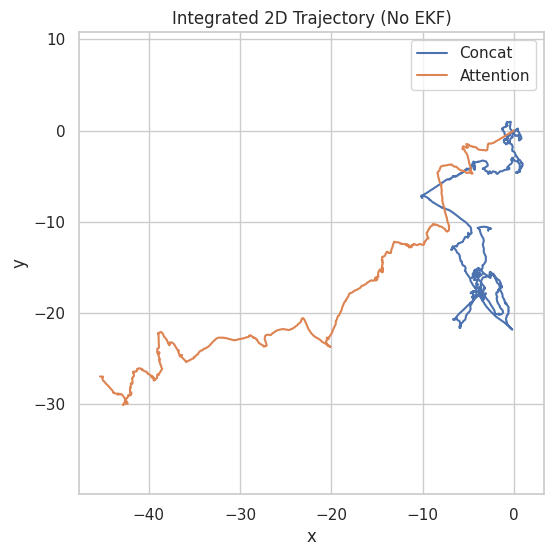

For TLIO EKF replacement path: use this notebook model output as measurement input in TLIO tracker update step.


In [26]:
def integrate_displacements(pred_disp, start_pos=None):
    """Simple trajectory integration baseline (no EKF)."""
    if start_pos is None:
        start_pos = np.zeros(3, dtype=np.float32)
    traj = [start_pos]
    cur = start_pos.astype(np.float32).copy()
    for d in pred_disp:
        cur = cur + d.astype(np.float32)
        traj.append(cur.copy())
    return np.asarray(traj)


def collect_predictions(model, loader):
    model.eval()
    preds = []
    with torch.no_grad():
        for x_imu, x_img, _ in loader:
            out = model(x_imu.to(DEVICE), x_img.to(DEVICE)).detach().cpu().numpy()
            preds.append(out)
    return np.concatenate(preds, axis=0)

pred_concat = collect_predictions(baseline_model, test_loader)
pred_attn = collect_predictions(attn_model, test_loader)
traj_concat = integrate_displacements(pred_concat)
traj_attn = integrate_displacements(pred_attn)

plt.figure(figsize=(6, 6))
plt.plot(traj_concat[:, 0], traj_concat[:, 1], label="Concat")
plt.plot(traj_attn[:, 0], traj_attn[:, 1], label="Attention")
plt.title("Integrated 2D Trajectory (No EKF)")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.axis("equal")
plt.show()

print("For TLIO EKF replacement path: use this notebook model output as measurement input in TLIO tracker update step.")